# F4 · Cohesión partidaria: Agreement Index, Rice y cohesión entrópica

## Objetivo
Mostrar cuán unido votó cada partido en las votaciones del boletín 11092-07, por
partido y por votación, y evaluar si los resultados dependen del índice o de las
votaciones incluidas.

## Entradas y organización
Se utilizan la matriz nominal, la afiliación por votación y la configuración de
análisis. Se usan tres índices: Agreement Index (principal), índice de Rice y cohesión
entrópica (contrastes). Los cálculos se ejecutan con las clases de `F4/src/analisis/`:
`IndicesCohesion` y `ResumenCohesion` (cohesion.py) y `SensibilidadCohesion`
(sensibilidad.py). El notebook no recalcula nada por su cuenta: llama a esas clases,
compara sus resultados con las tablas versionadas y muestra figuras. Solo escribe sus
figuras, en `F4/figures/cohesion/`.

### Cautelas de interpretación
- La cohesión describe **cuán unido** vota un partido, no **hacia dónde** vota. Un
  partido puede votar muy unido y estar al centro, o estar dividido.
- No existe un padrón verificable: los índices son descriptivos y no se ordenan como
  un ranking concluyente ni se etiquetan como cohesión "alta" o "baja".
- Los independientes (IND) no son un partido: se calculan, pero no se publican como
  cohesión partidaria.

In [1]:
import json
import platform
import subprocess
import sys
import tomllib
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'F4/src/analisis/cohesion.py').is_file()), None)
if raiz is None:
    raise FileNotFoundError('Guarda el notebook dentro del repositorio.')
sys.path.insert(0, str(raiz))
from F4.src.analisis.cohesion import ParametrosCohesion, ResumenCohesion  # noqa: E402
from F4.src.analisis.cohesion import (  # noqa: E402
    desde_repositorio as cohesion_desde_repositorio,
)
from F4.src.analisis.sensibilidad import SensibilidadCohesion  # noqa: E402

rutas = {
    'config': raiz / 'F4/config/analisis.toml',
    'manifiesto': raiz / 'F4/data/reports/manifiesto_corte.json',
    'nominal': raiz / 'F4/data/processed/matriz_nominal.csv',
    'afiliacion': raiz / 'F4/data/processed/afiliacion_por_votacion.csv',
    'cohesion': raiz / 'F4/data/results/partidos/cohesion_por_votacion.csv',
    'resumen': raiz / 'F4/data/results/partidos/resumen_cohesion.csv',
}
for nombre, ruta in rutas.items():
    if not ruta.is_file() or ruta.stat().st_size == 0:
        raise FileNotFoundError(f'Entrada ausente o vacía: {ruta.relative_to(raiz)}')
FIGURAS = raiz / 'F4/figures/cohesion'
FIGURAS.mkdir(parents=True, exist_ok=True)

with rutas['config'].open('rb') as archivo:
    config = tomllib.load(archivo)
manifiesto = json.loads(rutas['manifiesto'].read_text(encoding='utf-8'))
parametros = ParametrosCohesion.desde_toml(rutas['config'])

pd.set_option('display.max_columns', 30)
TEXTO, GRIS, GRILLA = '#0b0b0b', '#52514e', '#e4e3df'
COLORES_VOTO = {'Y': '#2a78d6', 'N': '#eb6834', 'A': '#1baf7a'}
ETIQUETA_VOTO = {'Y': 'Sí', 'N': 'No', 'A': 'Abstención'}
COLORES_INDICE = {'ai': '#4a3aa7', 'rice': '#c98500', 'entropia': '#d55181'}
ETIQUETA_INDICE = {'ai': 'Agreement Index', 'rice': 'Rice', 'entropia': 'Entropía'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})


figuras_generadas = []


def guardar(fig, nombre):
    figuras_generadas.append(nombre)
    fig.savefig(FIGURAS / nombre, dpi=160, bbox_inches='tight',
                metadata={'Software': None})


fechas = pd.read_csv(rutas['cohesion'], usecols=['fecha'])['fecha']
display(pd.Series({
    'Corte F3 (commit)': manifiesto['reproducibilidad']['commit_git'],
    'SHA-256 de la entrada': manifiesto['entrada']['sha256'],
    'Período': f'{fechas.min()[:10]} a {fechas.max()[:10]}',
    'Mínimo de decisiones por partido × votación (AI y entropía)':
        parametros.min_decisiones_publicacion,
    'Mínimo de votos Sí/No por partido × votación (Rice)':
        parametros.min_binarios_publicacion_rice,
    'Categorías de la entropía': parametros.categorias_entropia,
    'Mínimo de votaciones para el resumen por partido': parametros.min_votaciones_resumen,
    'Grupos no partidarios': ', '.join(parametros.grupos_no_partidarios),
}, name='valor').to_frame())

,valor
Corte F3 (commit),022d4d0ac3d453430e1473ac603ef5ee0ca29d9f
SHA-256 de la entrada,5bf21cbcb360da9074db00ac78de4ab53f2de3c061fa99...
Período,2023-05-08 a 2024-08-26
Mínimo de decisiones por partido × votación (AI y entropía),2
Mínimo de votos Sí/No por partido × votación (Rice),2
Categorías de la entropía,3
Mínimo de votaciones para el resumen por partido,2
Grupos no partidarios,IND


## 1. Índices por partido y votación
Se calculan los tres índices para cada partido vigente en cada votación. Un valor no
estimable queda como NA con su razón, nunca como 0. Una celda se **publica** solo si
el partido tiene al menos 2 decisiones en esa votación (AI y entropía) o al menos 2
votos Sí o No (Rice), y si no es el grupo de independientes. Con 1 integrante
cualquier índice vale 1 por definición y no informa sobre la unidad del partido.

In [2]:
tabla = cohesion_desde_repositorio(raiz)
guardado = rutas['cohesion'].read_text(encoding='utf-8')
print('Coincide con cohesion_por_votacion.csv:',
      tabla.to_csv(index=False, lineterminator='\n') == guardado)

display(pd.Series({
    'Celdas partido × votación': len(tabla),
    'Publicables (AI y entropía)': int(tabla['publicable_ai_entropia'].sum()),
    'Publicables (Rice)': int(tabla['publicable_rice'].sum()),
    'Votaciones unánimes en la sala': int(tabla.groupby('votacion_id')[
        'votacion_unanime_sala'].first().sum()),
}, name='valor').to_frame())
display(tabla['razon_no_publicable'].fillna('publicable').value_counts()
        .rename('celdas').to_frame())

Coincide con cohesion_por_votacion.csv: True


,valor
Celdas partido × votación,298
Publicables (AI y entropía),207
Publicables (Rice),204
Votaciones unánimes en la sala,2


,celdas
razon_no_publicable,
publicable,204
T_bajo_minimo,76
grupo_independientes,15
binarios_bajo_minimo_rice,3


La figura muestra el Agreement Index de cada partido en cada votación. Las celdas
rayadas no se publican (menos de 2 decisiones) y las vacías corresponden a votaciones
en que el partido no tuvo decisiones registradas. Las filas van ordenadas por tamaño
del partido, no por su cohesión.

Coincide con resumen_cohesion.csv: True


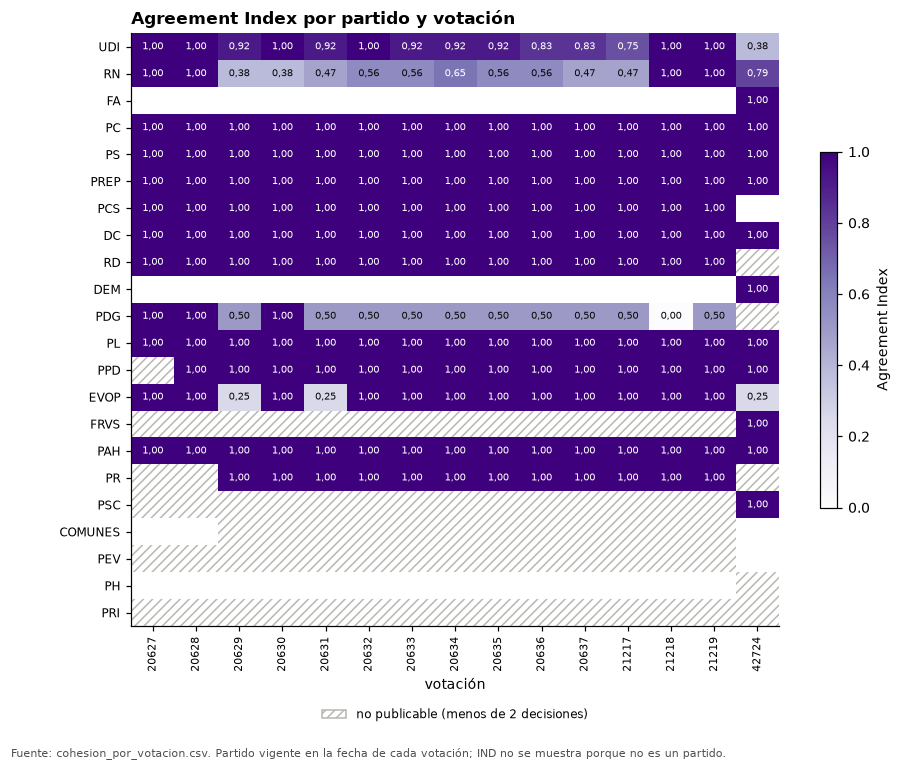

In [3]:
resumen = ResumenCohesion(parametros).calcular(tabla)
print('Coincide con resumen_cohesion.csv:',
      resumen.to_csv(index=False, lineterminator='\n')
      == rutas['resumen'].read_text(encoding='utf-8'))

partidos = resumen[resumen['tipo_grupo'] == 'partido'].sort_values(
    ['bancada_max_T', 'partido_alias'], ascending=[False, True])['partido_alias'].tolist()
votaciones = sorted(tabla['votacion_id'].unique(), key=lambda v: (
    tabla.loc[tabla['votacion_id'] == v, 'fecha'].iloc[0], v))
ai = tabla.pivot_table(index='partido_alias', columns='votacion_id',
                       values='agreement_index', aggfunc='first')
publicable = tabla.pivot_table(index='partido_alias', columns='votacion_id',
                               values='publicable_ai_entropia', aggfunc='first')
ai = ai.reindex(index=partidos, columns=votaciones)
publicable = publicable.reindex(index=partidos, columns=votaciones)
valores = ai.where(publicable.fillna(False).astype(bool))

fig, ax = plt.subplots(figsize=(9.5, 7))
ax.set_facecolor('white')
imagen = ax.imshow(valores.to_numpy(dtype=float), aspect='auto', cmap='Purples',
                   vmin=0, vmax=1)
for (i, j), v in np.ndenumerate(ai.to_numpy(dtype=float)):
    pub = bool(publicable.iloc[i, j]) if pd.notna(publicable.iloc[i, j]) else False
    if pd.notna(v) and pub:
        ax.text(j, i, f'{v:.2f}'.replace('.', ','), ha='center', va='center',
                fontsize=6.5, color='white' if v > 0.6 else TEXTO)
    elif pd.notna(v):
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch='////',
                                   edgecolor='#b8b7b2', lw=0))
ax.set_xticks(range(len(votaciones)), votaciones, rotation=90, fontsize=7)
ax.set_yticks(range(len(partidos)), partidos, fontsize=8)
ax.set_xlabel('votación')
ax.set_title('Agreement Index por partido y votación', loc='left', fontweight='bold')
fig.colorbar(imagen, ax=ax, shrink=0.6, label='Agreement Index')
ax.legend(handles=[Patch(facecolor='white', edgecolor='#b8b7b2', hatch='////',
                         label='no publicable (menos de 2 decisiones)')],
          frameon=False, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12))
fig.text(0.01, -0.06, 'Fuente: cohesion_por_votacion.csv. Partido vigente en la fecha '
         'de cada votación; IND no se muestra porque no es un partido.',
         fontsize=7.5, color=GRIS)
guardar(fig, 'ai_partido_votacion.png')
plt.show()

## 2. Resumen por partido
Para cada partido se resume la distribución de sus valores por votación con la
**mediana**, que no se deja arrastrar por una votación extrema, junto al rango
intercuartílico, el mínimo, el máximo, el número de votaciones válidas y los conteos
Sí, No y Abstención. Un partido tiene resumen publicable si cuenta con al menos 2
votaciones válidas.

In [4]:
columnas = ['partido_alias', 'tipo_grupo', 'n_validas_ai', 'mediana_ai', 'riq_ai',
            'min_ai', 'max_ai', 'mediana_rice', 'mediana_entropia', 'total_Y', 'total_N',
            'total_A', 'total_T', 'publicable_resumen', 'razon_no_publicable_resumen']
display(resumen[columnas].round(3).style.hide(axis='index'))

partido_alias,tipo_grupo,n_validas_ai,mediana_ai,riq_ai,min_ai,max_ai,mediana_rice,mediana_entropia,total_Y,total_N,total_A,total_T,publicable_resumen,razon_no_publicable_resumen
COMUNES,partido,0,nan,nan,nan,nan,nan,nan,12,0,0,12,False,votaciones_validas_bajo_minimo
DC,partido,15,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,60,0,0,60,True,nan
DEM,partido,1,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3,0,0,3,False,votaciones_validas_bajo_minimo
EVOP,partido,15,1.000000,0.000000,0.250000,1.000000,1.000000,1.000000,21,7,2,30,True,nan
FA,partido,1,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,13,0,0,13,False,votaciones_validas_bajo_minimo
FRVS,partido,1,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,16,0,0,16,False,votaciones_validas_bajo_minimo
IND,independientes,0,nan,nan,nan,nan,nan,nan,375,109,19,503,False,grupo_independientes
PAH,partido,15,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,30,0,0,30,True,nan
PC,partido,15,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,164,0,0,164,True,nan
PCS,partido,14,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,93,0,0,93,True,nan


La figura principal muestra, para cada partido con resumen publicable, el valor de
cada índice en cada votación (puntos) y su mediana (rombo). Cada índice tiene su propio
panel y su propia escala: los valores no son comparables entre índices. El último panel
muestra la composición de las decisiones del partido, con las abstenciones destacadas.

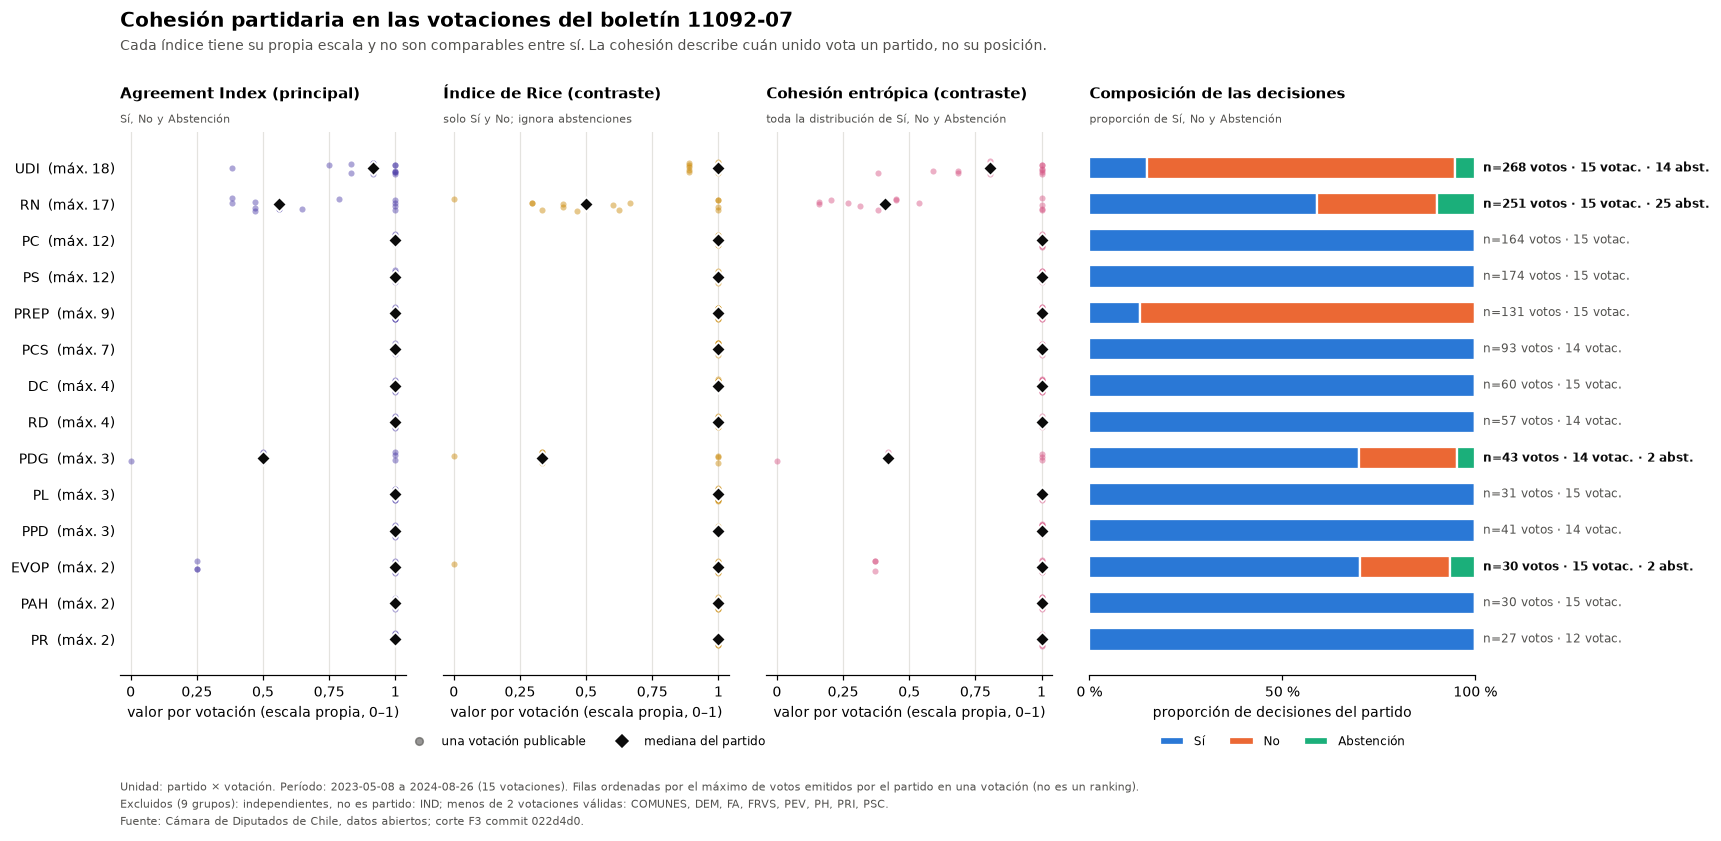

In [5]:
pub = resumen[resumen['publicable_resumen']].sort_values(
    ['bancada_max_T', 'partido_alias'], ascending=[False, True])
filas = pub['partido_alias'].tolist()
fila = {p: i for i, p in enumerate(filas)}
excluidos = resumen[~resumen['publicable_resumen']]
INDICES_PANEL = [
    ('ai', 'agreement_index', 'publicable_ai_entropia', 'mediana_ai',
     'Agreement Index (principal)', 'Sí, No y Abstención'),
    ('rice', 'rice', 'publicable_rice', 'mediana_rice',
     'Índice de Rice (contraste)', 'solo Sí y No; ignora abstenciones'),
    ('entropia', 'cohesion_entropica', 'publicable_ai_entropia', 'mediana_entropia',
     'Cohesión entrópica (contraste)', 'toda la distribución de Sí, No y Abstención'),
]
rng = np.random.default_rng(config['reproducibilidad']['semilla'])
fig, ejes = plt.subplots(1, 4, figsize=(16, 7.6), sharey=True,
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.35], 'wspace': 0.12})
for ax, (clave, col, col_pub, col_med, titulo, nota) in zip(ejes[:3], INDICES_PANEL):
    datos = tabla[tabla['partido_alias'].isin(filas) & tabla[col_pub]
                  & tabla[col].notna()]
    # Desplazamiento vertical pequeño para que los puntos repetidos no se tapen;
    # no cambia el valor del índice.
    yy = datos['partido_alias'].map(fila) + rng.uniform(-0.18, 0.18, len(datos))
    ax.scatter(datos[col], yy, s=16, color=COLORES_INDICE[clave], alpha=0.45,
               linewidths=0, zorder=2)
    ax.scatter(pub[col_med], pub['partido_alias'].map(fila), marker='D', s=45,
               color=TEXTO, edgecolors='white', linewidths=1.2, zorder=3)
    ax.set_xlim(-0.04, 1.04)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1], ['0', '0,25', '0,5', '0,75', '1'])
    ax.grid(axis='x', color=GRILLA, lw=0.8, zorder=0)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.set_title(titulo, loc='left', fontsize=10, fontweight='bold', pad=22)
    ax.text(0, 1.012, nota, transform=ax.transAxes, fontsize=7.5, color=GRIS,
            va='bottom')
    ax.set_xlabel('valor por votación (escala propia, 0–1)')
ejes[0].set_yticks(range(len(filas)),
                   [f'{p}  (máx. {int(t)})' for p, t in zip(filas, pub['bancada_max_T'])])
ejes[0].invert_yaxis()

ax = ejes[3]
izq = np.zeros(len(filas))
for k in ('Y', 'N', 'A'):
    prop = (pub[f'total_{k}'] / pub['total_T']).to_numpy()
    ax.barh(range(len(filas)), prop, left=izq, height=0.62, color=COLORES_VOTO[k],
            edgecolor='white', linewidth=1.5, label=ETIQUETA_VOTO[k])
    izq += prop
for i, (_, r) in enumerate(pub.iterrows()):
    a = int(r['total_A'])
    texto = f"n={int(r['total_T'])} votos · {int(r['n_validas_ai'])} votac."
    ax.text(1.02, i, texto + (f' · {a} abst.' if a else ''), va='center', fontsize=7.8,
            color=TEXTO if a else GRIS, fontweight='bold' if a else 'normal')
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.5, 1], ['0 %', '50 %', '100 %'])
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.set_title('Composición de las decisiones', loc='left', fontsize=10, fontweight='bold',
             pad=22)
ax.text(0, 1.012, 'proporción de Sí, No y Abstención', transform=ax.transAxes,
        fontsize=7.5, color=GRIS, va='bottom')
ax.set_xlabel('proporción de decisiones del partido')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=3, frameon=False,
          fontsize=8)
ejes[1].legend(handles=[
    Line2D([], [], marker='o', ls='', color=GRIS, alpha=0.6, ms=5,
           label='una votación publicable'),
    Line2D([], [], marker='D', ls='', color=TEXTO, ms=6, label='mediana del partido')],
    loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=2, frameon=False, fontsize=8)

RAZONES = {'grupo_independientes': 'independientes, no es partido',
           'votaciones_validas_bajo_minimo': 'menos de 2 votaciones válidas'}
grupos_excluidos = '; '.join(
    f"{texto}: {', '.join(sorted(excluidos.loc[excluidos['razon_no_publicable_resumen'] == clave, 'partido_alias']))}"  # noqa: E501
    for clave, texto in RAZONES.items()
    if (excluidos['razon_no_publicable_resumen'] == clave).any())
fig.suptitle('Cohesión partidaria en las votaciones del boletín 11092-07', x=0.08,
             y=0.995, ha='left', fontsize=13, fontweight='bold')
fig.text(0.08, 0.948, 'Cada índice tiene su propia escala y no son comparables entre sí. '
         'La cohesión describe cuán unido vota un partido, no su posición.',
         fontsize=9, color=GRIS)
fig.text(0.08, 0.015,
         f"Unidad: partido × votación. Período: {fechas.min()[:10]} a {fechas.max()[:10]} "
         f"({tabla['votacion_id'].nunique()} votaciones). Filas ordenadas por el máximo de "
         "votos emitidos por el partido en una votación (no es un ranking).\n"
         f"Excluidos ({len(excluidos)} grupos): {grupos_excluidos}.\n"
         f"Fuente: Cámara de Diputados de Chile, datos abiertos; corte F3 commit "
         f"{manifiesto['reproducibilidad']['commit_git'][:7]}.",
         fontsize=7.5, color=GRIS, va='bottom', linespacing=1.5)
fig.subplots_adjust(left=0.08, right=0.85, top=0.85, bottom=0.2)
guardar(fig, 'cohesion_partidos.png')
plt.show()

## 3. Diferencias entre índices
Los tres índices coinciden en las celdas donde el partido votó todo igual. Se separan
en las celdas con abstenciones, porque Rice solo cuenta los votos Sí y No. Cada punto
de la figura es una celda partido × votación publicable, coloreada según la proporción
de abstenciones del partido en esa votación.

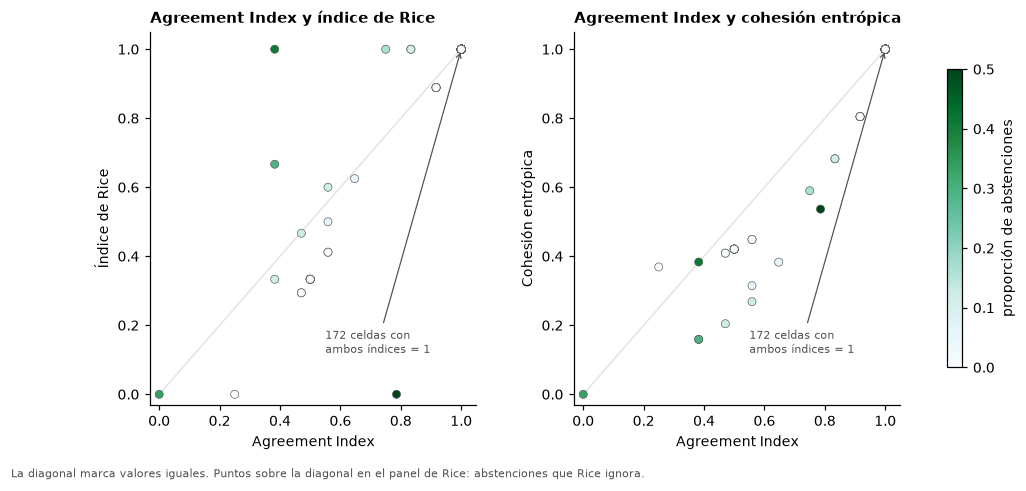

In [6]:
celdas = tabla[tabla['publicable_ai_entropia'] & tabla['publicable_rice']
               & (tabla['tipo_grupo'] == 'partido')].copy()
celdas['prop_abstencion'] = celdas['A'] / celdas['T']
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True,
                         gridspec_kw={'wspace': 0.3})
for ax, (col, etiqueta) in zip(ejes, [('rice', 'Índice de Rice'),
                                      ('cohesion_entropica', 'Cohesión entrópica')]):
    ax.plot([0, 1], [0, 1], color=GRILLA, lw=1, zorder=0)
    puntos = ax.scatter(celdas['agreement_index'], celdas[col],
                        c=celdas['prop_abstencion'], cmap='BuGn', vmin=0, vmax=0.5,
                        s=28, edgecolors=GRIS, linewidths=0.4, zorder=2)
    iguales = int(((celdas['agreement_index'] == 1) & (celdas[col] == 1)).sum())
    ax.annotate(f'{iguales} celdas con\nambos índices = 1', xy=(1, 1),
                xytext=(0.55, 0.12), fontsize=7.5, color=GRIS,
                arrowprops={'arrowstyle': '->', 'color': GRIS, 'lw': 0.8})
    ax.set_xlim(-0.03, 1.05)
    ax.set_ylim(-0.03, 1.05)
    ax.set_xlabel('Agreement Index')
    ax.set_ylabel(etiqueta)
    ax.set_title(f'Agreement Index y {etiqueta[0].lower() + etiqueta[1:]}', loc='left',
                 fontweight='bold', fontsize=10)
fig.colorbar(puntos, ax=ejes, shrink=0.8, label='proporción de abstenciones')
fig.text(0.01, -0.04, 'La diagonal marca valores iguales. Puntos sobre la diagonal en '
         'el panel de Rice: abstenciones que Rice ignora.', fontsize=7.5, color=GRIS)
guardar(fig, 'contraste_indices.png')
plt.show()

La tabla compara las tres medianas y los conteos de cada partido publicable. En UDI,
Rice supera al Agreement Index porque ignora sus abstenciones. En RN y PDG, que se
dividen entre Sí y No, Rice queda por debajo del Agreement Index.

In [7]:
comparacion = pub[['partido_alias', 'mediana_ai', 'mediana_rice', 'mediana_entropia',
                   'total_Y', 'total_N', 'total_A', 'total_T']].copy()
comparacion['prop_abstencion'] = comparacion['total_A'] / comparacion['total_T']
comparacion['rice_menos_ai'] = comparacion['mediana_rice'] - comparacion['mediana_ai']
display(comparacion.round(3).style.hide(axis='index'))

partido_alias,mediana_ai,mediana_rice,mediana_entropia,total_Y,total_N,total_A,total_T,prop_abstencion,rice_menos_ai
UDI,0.917000,1.000000,0.805000,40,214,14,268,0.052000,0.083000
RN,0.559000,0.500000,0.409000,148,78,25,251,0.100000,-0.059000
PC,1.000000,1.000000,1.000000,164,0,0,164,0.000000,0.000000
PS,1.000000,1.000000,1.000000,174,0,0,174,0.000000,0.000000
PREP,1.000000,1.000000,1.000000,17,114,0,131,0.000000,0.000000
PCS,1.000000,1.000000,1.000000,93,0,0,93,0.000000,0.000000
DC,1.000000,1.000000,1.000000,60,0,0,60,0.000000,0.000000
RD,1.000000,1.000000,1.000000,57,0,0,57,0.000000,0.000000
PDG,0.500000,0.333000,0.421000,30,11,2,43,0.047000,-0.167000
PL,1.000000,1.000000,1.000000,31,0,0,31,0.000000,0.000000


## 4. Sensibilidad de la cohesión
Se evalúa si la mediana de cada partido cambia en cuatro escenarios:

- **retiro de una votación**: se recalcula el resumen sin cada una de las 15 votaciones;
- **sin votaciones unánimes**: se retiran juntas las dos votaciones unánimes en la sala;
- **mínimo de 3 decisiones**: se exige un mínimo mayor por partido × votación;
- **índice alternativo**: Rice y entropía frente al Agreement Index con los mismos datos.

Los valores deben coincidir con las filas de cohesión de `sensibilidad.csv`.

In [8]:
umbrales = tuple(config['cobertura']['umbrales_sensibilidad'])
sensibilidad = SensibilidadCohesion(parametros, umbrales_cobertura=umbrales).calcular(tabla)
versionada = pd.read_csv(raiz / 'F4/data/reports/sensibilidad.csv')
versionada = versionada[versionada['familia'] == 'cohesion_partidaria']
print('Comparaciones:', len(sensibilidad), '· en sensibilidad.csv:', len(versionada))
print(sensibilidad['escenario'].value_counts().to_string())

# Los índices de cohesión no dependen del umbral de cobertura: se usa el primero.
sens = sensibilidad[sensibilidad['umbral_cobertura'] == umbrales[0]]

Comparaciones: 3657 · en sensibilidad.csv: 3657
escenario
retiro_una_votacion        3105
sin_votaciones_unanimes     207
minimo_decisiones_3         207
indice_alternativo          138


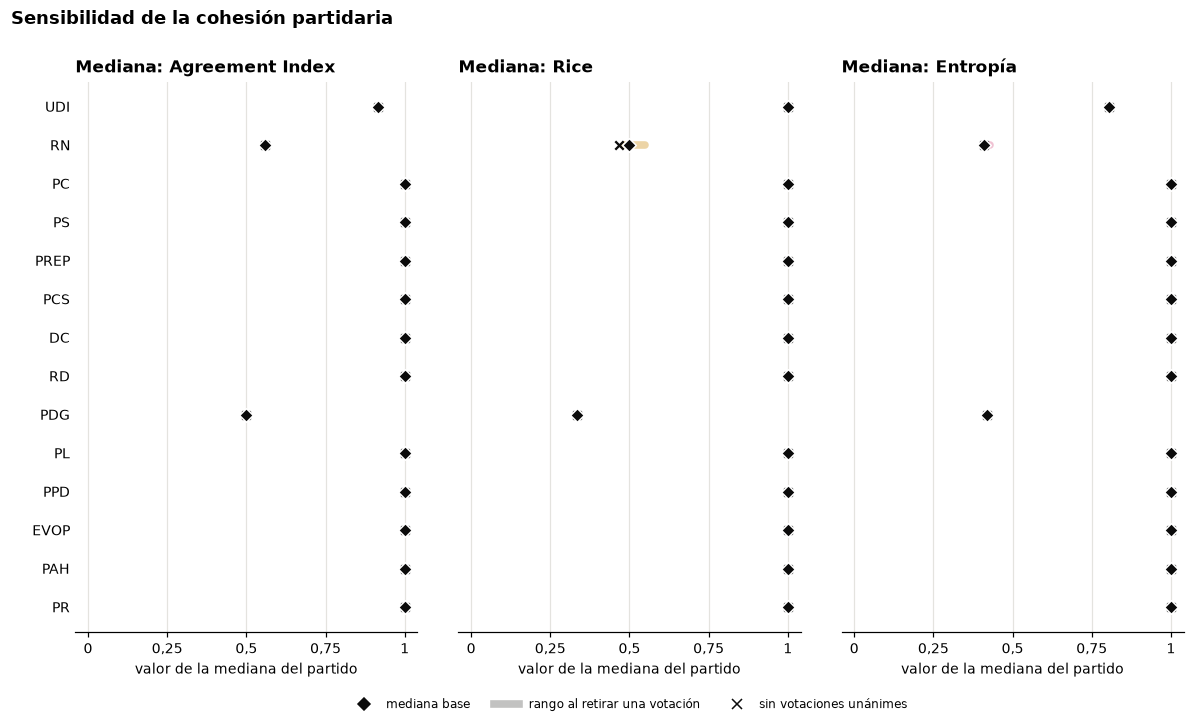

In [9]:
METODOS = {'ai': 'mediana_agreement_index', 'rice': 'mediana_rice',
           'entropia': 'mediana_cohesion_entropica'}
fig, ejes = plt.subplots(1, 3, figsize=(13, 6.5), sharey=True,
                         gridspec_kw={'wspace': 0.12})
for ax, (clave, metodo) in zip(ejes, METODOS.items()):
    m = sens[(sens['metodo'] == metodo) & sens['id'].isin(filas)]
    retiro = m[m['escenario'] == 'retiro_una_votacion'].groupby('id')['valor_alternativo']
    base = m.groupby('id')['valor_base'].first()
    sin_un = m[m['escenario'] == 'sin_votaciones_unanimes'].set_index('id')[
        'valor_alternativo']
    for p in filas:
        y = fila[p]
        if p in retiro.groups:
            ax.plot([retiro.min()[p], retiro.max()[p]], [y, y], color=COLORES_INDICE[clave],
                    lw=5, alpha=0.35, solid_capstyle='round')
        if p in sin_un.index and pd.notna(sin_un[p]):
            ax.scatter(sin_un[p], y, marker='x', s=30, color=TEXTO, zorder=3)
        if pd.notna(base.get(p)):
            ax.scatter(base[p], y, marker='D', s=40, color=TEXTO, edgecolors='white',
                       linewidths=1, zorder=4)
    ax.set_xlim(-0.04, 1.04)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1], ['0', '0,25', '0,5', '0,75', '1'])
    ax.grid(axis='x', color=GRILLA, lw=0.8, zorder=0)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.set_title(f'Mediana: {ETIQUETA_INDICE[clave]}', loc='left', fontweight='bold')
    ax.set_xlabel('valor de la mediana del partido')
ejes[0].set_yticks(range(len(filas)), filas)
ejes[0].invert_yaxis()
ejes[1].legend(handles=[
    Line2D([], [], marker='D', ls='', color=TEXTO, ms=6, label='mediana base'),
    Line2D([], [], lw=5, color=GRIS, alpha=0.35,
           label='rango al retirar una votación'),
    Line2D([], [], marker='x', ls='', color=TEXTO, ms=6, label='sin votaciones unánimes')],
    loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=8)
fig.suptitle('Sensibilidad de la cohesión partidaria', x=0.08, y=0.98, ha='left',
             fontsize=12, fontweight='bold')
guardar(fig, 'sensibilidad_cohesion.png')
plt.show()

### 4.1 Cambios de publicabilidad y contraste entre índices
Con un mínimo de 3 decisiones por partido × votación, algunos partidos pequeños dejan
de tener resumen publicable. El contraste entre índices muestra la diferencia entre la
mediana de Rice o de la entropía y la mediana del Agreement Index.

In [10]:
minimo = sens[(sens['escenario'].str.startswith('minimo_decisiones'))
              & (sens['metodo'] == 'mediana_agreement_index')
              & (sens['publicable_base'] != sens['publicable_alternativo'])]
display(minimo[['id', 'escenario', 'publicable_base', 'publicable_alternativo',
                'valor_base', 'valor_alternativo']].style.hide(axis='index'))
contraste = (sens[sens['escenario'] == 'indice_alternativo']
             .pivot_table(index='id', columns='metodo', values='diferencia', aggfunc='first')
             .reindex(filas))
display(contraste.round(3))

id,escenario,publicable_base,publicable_alternativo,valor_base,valor_alternativo
EVOP,minimo_decisiones_3,True,False,1.000000,nan
PAH,minimo_decisiones_3,True,False,1.000000,nan
PL,minimo_decisiones_3,True,False,1.000000,1.000000
PR,minimo_decisiones_3,True,False,1.000000,nan


metodo,contraste_entropia_vs_ai,contraste_rice_vs_ai
id,,
UDI,-0.112,0.083
RN,-0.150,-0.059
PC,0.000,0.000
PS,0.000,0.000
PREP,0.000,0.000
PCS,0.000,0.000
DC,0.000,0.000
RD,0.000,0.000
PDG,-0.079,-0.167


## 5. Reproducibilidad

In [11]:
def _git(*args):
    try:
        return subprocess.run(['git', *args], cwd=raiz, capture_output=True, text=True,
                              check=True).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        return None


# --no-optional-locks: consultar el estado sin bloquear el índice del repositorio.
estado_git = _git('--no-optional-locks', 'status', '--porcelain') or ''
display(pd.Series({
    'Commit del repositorio': _git('rev-parse', 'HEAD'),
    # El propio notebook cambia al ejecutarse, por eso no cuenta como modificación.
    'Otros archivos modificados': (
        [linea for linea in estado_git.splitlines()
         if not linea.endswith('.ipynb')] or 'ninguno'),
    'Python': platform.python_version(),
    'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__,
    'Commit del corte F3': manifiesto['reproducibilidad']['commit_git'],
    'Semilla (desplazamiento de puntos)': config['reproducibilidad']['semilla'],
}, name='valor').to_frame())
display(pd.Series(figuras_generadas, name='figuras generadas').to_frame())

,valor
Commit del repositorio,e971acb6b767338551068b26faa1992fcabbfa67
Otros archivos modificados,[?? F4/figures/cohesion/]
Python,3.12.14
pandas,3.0.5
matplotlib,3.11.1
Commit del corte F3,022d4d0ac3d453430e1473ac603ef5ee0ca29d9f
Semilla (desplazamiento de puntos),42


,figuras generadas
0,ai_partido_votacion.png
1,cohesion_partidos.png
2,contraste_indices.png
3,sensibilidad_cohesion.png


## 6. Síntesis
- Con las tres medidas, la mayoría de los partidos con resumen publicable vota unido en
  casi todas las votaciones del boletín.
- Las diferencias aparecen en pocos partidos y votaciones, y se concentran donde hay
  abstenciones o divisiones entre Sí y No dentro del partido.
- En las votaciones con abstenciones los índices se separan: en 2024, UDI (10 No y 7
  abstenciones) tiene Rice 1 y AI 0,38; RN (1 Sí, 1 No y 12 abstenciones) tiene Rice 0
  y AI 0,79.
- Las medianas son estables al retirar votaciones; el mínimo de decisiones sí cambia
  qué partidos pequeños tienen resumen publicable.
- Los resultados describen el comportamiento observado en este corpus: no son un
  ranking ni una medida de disciplina partidaria.

In [12]:
display(pd.DataFrame({'valor': [
    len(tabla),
    int(tabla['publicable_ai_entropia'].sum()),
    int(tabla['publicable_rice'].sum()),
    int(resumen['publicable_resumen'].sum()),
    len(excluidos),
    int((pub['mediana_ai'] < 1).sum()),
    ', '.join(pub.loc[pub['mediana_ai'] < 1, 'partido_alias']) or 'ninguno',
]}, index=[
    'Celdas partido × votación', 'Publicables (AI y entropía)', 'Publicables (Rice)',
    'Partidos con resumen publicable', 'Grupos sin resumen publicable',
    'Partidos con mediana AI menor que 1', 'Esos partidos',
]))

,valor
Celdas partido × votación,298
Publicables (AI y entropía),207
Publicables (Rice),204
Partidos con resumen publicable,14
Grupos sin resumen publicable,9
Partidos con mediana AI menor que 1,3
Esos partidos,"UDI, RN, PDG"
